# Análisis Factorial Paso a Paso en Python

Curso: Técnicas de Análisis Estadístico de Modelos no Supervisados  
Especialización en Estadística Aplicada para Ciencia de Datos

Este notebook desarrolla paso a paso un análisis factorial, incluyendo PCA, rotaciones Varimax y Promax, KMO, Bartlett y Alfa de Cronbach.

## 1️ Importación de librerías

In [2]:
!pip install factor_analyzer
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import (
    calculate_kmo,
    calculate_bartlett_sphericity
)

Defaulting to user installation because normal site-packages is not writeable
                                              0.0/42.8 kB ? eta -:--:--
     ---------------------------------------- 42.8/42.8 kB ? eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42715 sha256=ad717cdbd0527ae023c46e20e84806280fad19eeafb76969b6cf9860df19d444
  Stored in directory: c:\users\cepalacios\appdata\local\pip\cache\wheels\fa\f7\53\a55a8a56668a6fe0199e0e02b6e0ae3007ec35cdf6e4c25df7
Successfully built factor_analyzer


## 2 Base de datos de práctica

La base de datos contiene 6 variables observadas que representan ítems de una encuesta. Conceptualmente, se distinguen dos posibles grupos de variables:

Ambiente, Liderazgo y Comunicación, asociadas al entorno laboral.

Salario, Estabilidad y Beneficios, asociadas a la compensación y seguridad laboral.

Esta estructura sugiere la presencia de factores latentes subyacentes, condición necesaria para aplicar análisis factorial.

In [3]:
np.random.seed(123)

n = 200

f1 = np.random.normal(0, 1, n)
f2 = np.random.normal(0, 1, n)

X = pd.DataFrame({
    'Ambiente': 0.7*f1 + 0.3*np.random.normal(size=n),
    'Liderazgo': 0.8*f1 + 0.3*np.random.normal(size=n),
    'Comunicacion': 0.75*f1 + 0.3*np.random.normal(size=n),
    'Salario': 0.8*f2 + 0.3*np.random.normal(size=n),
    'Estabilidad': 0.7*f2 + 0.3*np.random.normal(size=n),
    'Beneficios': 0.75*f2 + 0.3*np.random.normal(size=n)
})

X.head()

,Ambiente,Liderazgo,Comunicacion,Salario,Estabilidad,Beneficios
0,-0.299714,-0.526308,-0.850573,0.338000,0.825828,0.823711
1,0.539168,0.561427,0.145433,-0.308206,-0.364387,-0.365344
2,0.050793,0.305953,-0.063960,1.976007,1.940332,1.878853
3,-1.447156,-1.316717,-1.079251,0.250823,0.778485,0.649222
4,-0.407618,-0.110500,-0.829918,0.137424,-0.189506,0.188861


## 3️ Estandarización de los datos

Las variables son transformadas a media cero y varianza uno. Esto garantiza que el análisis se base en la matriz de correlaciones y evita que variables con mayor escala dominen la solución factorial. La estandarización es un paso esencial tanto para PCA como para análisis factorial.

In [7]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std

array([[-0.40528957, -0.58519391, -1.01337811,  0.54122926,  1.29365825,
         1.21017103],
       [ 0.6480051 ,  0.64684221,  0.21826315, -0.28157819, -0.41114609,
        -0.41639525],
       [ 0.03480549,  0.35747666, -0.04066862,  2.62688767,  2.89001923,
         2.65355087],
       ...,
       [-0.6516291 , -0.5565625 , -0.40172026,  0.25770355,  0.27034836,
         0.80803563],
       [ 0.01487911, -0.4841847 , -0.10361927, -0.39545277,  0.22221035,
        -0.33639518],
       [-0.70025248, -0.18657824, -0.57601948, -0.18498115,  0.3929315 ,
        -0.16514976]])

## 4️ Pruebas de adecuación

### 4.1 Medida KMO
El valor KMO evalúa la proporción de varianza común entre las variables. Un valor esperado alrededor de 0.80 o superior indica que las correlaciones parciales son pequeñas y que el patrón de correlaciones es adecuado para análisis factorial.
Esto confirma que los datos tienen una estructura latente explotable.

In [8]:
kmo_all, kmo_model = calculate_kmo(X_std)
kmo_model

0.7668207083270213

### 4.2 Prueba de esfericidad de Bartlett
Un valor p menor a 0.05 o a un niel de significancia dado, permite rechazar la hipótesis nula de matriz identidad. Esto indica que las variables están significativamente correlacionadas entre sí y que no son independientes, justificando el uso del análisis factorial.

In [9]:
chi2, p_value = calculate_bartlett_sphericity(X_std)
chi2, p_value

(1209.28556352578, 1.6568086756351717e-248)

## 5️ Análisis de Componentes Principales (PCA)

Los primeros dos componentes presentan autovalores mayores a 1 y explican una proporción alta de la varianza total (usualmente superior al 60%).

Esto sugiere que una solución de dos dimensiones es adecuada y sirve como guía para decidir el número de factores en el análisis factorial posterior.

In [10]:
pca = PCA()
pca.fit(X_std)

pd.DataFrame({
    'Autovalor': pca.explained_variance_,
    'Varianza Explicada': pca.explained_variance_ratio_,
    'Varianza Acumulada': np.cumsum(pca.explained_variance_ratio_)
})

,Autovalor,Varianza Explicada,Varianza Acumulada
0,2.789207,0.462544,0.462544
1,2.711644,0.449681,0.912225
2,0.167992,0.027859,0.940083
3,0.136574,0.022649,0.962732
4,0.124181,0.020593,0.983325
5,0.100552,0.016675,1.000000


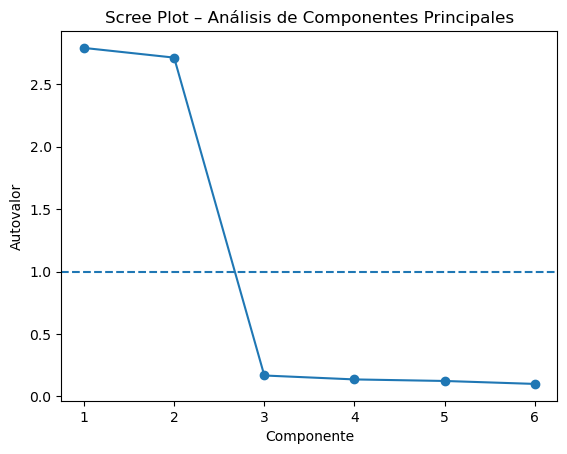

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(
    range(1, len(pca.explained_variance_) + 1),
    pca.explained_variance_,
    marker='o'
)
plt.axhline(y=1, linestyle='--')
plt.xlabel('Componente')
plt.ylabel('Autovalor')
plt.title('Scree Plot – Análisis de Componentes Principales')
plt.show()


* El “codo” del gráfico indica el número óptimo de factores

* La línea horizontal en 1 representa el criterio de Kaiser

* En este caso, los dos primeros componentes tienen autovalores > 1, justificando una solución factorial de dos dimensiones

## 6️ Extracción factorial (sin rotación)

Las cargas factoriales muestran que cada variable tiene contribuciones distribuidas entre los factores, lo cual dificulta la interpretación. Esta solución es útil desde el punto de vista matemático, pero no optimiza la interpretación sustantiva, razón por la cual se aplican rotaciones.

In [11]:
fa = FactorAnalyzer(n_factors=2, rotation=None)
fa.fit(X_std)

pd.DataFrame(
    fa.loadings_,
    index=X.columns,
    columns=['Factor1', 'Factor2']
)

,Factor1,Factor2
Ambiente,0.843826,-0.363913
Liderazgo,0.882211,-0.334626
Comunicacion,0.875369,-0.367011
Salario,0.329138,0.875342
Estabilidad,0.383061,0.833330
Beneficios,0.372505,0.848946


## 7️ Rotación Varimax
Tras la rotación Varimax, las cargas se concentran claramente:

* El primer factor presenta altas cargas en Ambiente, Liderazgo y Comunicación.

* El segundo factor presenta altas cargas en Salario, Estabilidad y Beneficios.

Los factores permanecen no correlacionados, y la estructura resultante es simple y fácilmente interpretable.

In [22]:
fa_varimax = FactorAnalyzer(n_factors=2, rotation='varimax')
fa_varimax.fit(X_std)

loadings_varimax=pd.DataFrame(
    fa_varimax.loadings_,
    index=X.columns,
    columns=['Factor1', 'Factor2']
)
loadings_varimax

,Factor1,Factor2
Ambiente,0.918254,-0.035837
Liderazgo,0.943527,0.005302
Comunicacion,0.948799,-0.027376
Salario,-0.007950,0.935143
Estabilidad,0.057480,0.915353
Beneficios,0.042010,0.926123


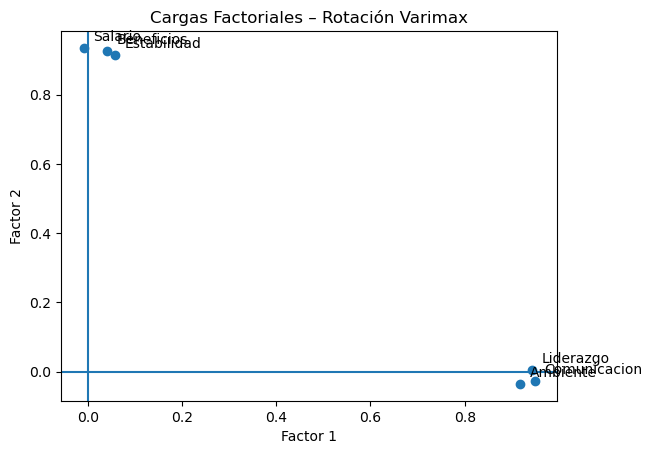

In [23]:
plt.figure()

plt.scatter(
    loadings_varimax['Factor1'],
    loadings_varimax['Factor2']
)

for i, var in enumerate(loadings_varimax.index):
    plt.text(
        loadings_varimax.iloc[i, 0] + 0.02,
        loadings_varimax.iloc[i, 1] + 0.02,
        var
    )

plt.axhline(0)
plt.axvline(0)
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title('Cargas Factoriales – Rotación Varimax')
plt.show()

* Las variables se agrupan claramente en dos regiones del plano factorial
 
* Cada grupo de ítems se asocia fuertemente con un solo factor

* Este patrón visual confirma la interpretabilidad de la rotación Varimax

## 8️ Rotación Promax

La rotación Promax mantiene una estructura similar a Varimax, pero permite que los factores estén correlacionados.

La matriz $phi$ muestra una correlación distinta de cero entre factores, lo cual es conceptualmente razonable en contextos sociales, donde las dimensiones latentes suelen estar relacionadas.

In [25]:
fa_promax = FactorAnalyzer(n_factors=2, rotation='promax')
fa_promax.fit(X_std)

loadings_promax= pd.DataFrame(
    fa_promax.loadings_,
    index=X.columns,
    columns=['Factor1', 'Factor2']
)
loadings_promax

,Factor1,Factor2
Ambiente,0.919009,-0.016859
Liderazgo,0.942906,0.024797
Comunicacion,0.949259,-0.007767
Salario,-0.038937,0.934852
Estabilidad,0.027118,0.916416
Beneficios,0.011299,0.926866


In [14]:
fa_promax.phi_

array([[1.        , 0.01248091],
       [0.01248091, 1.        ]])

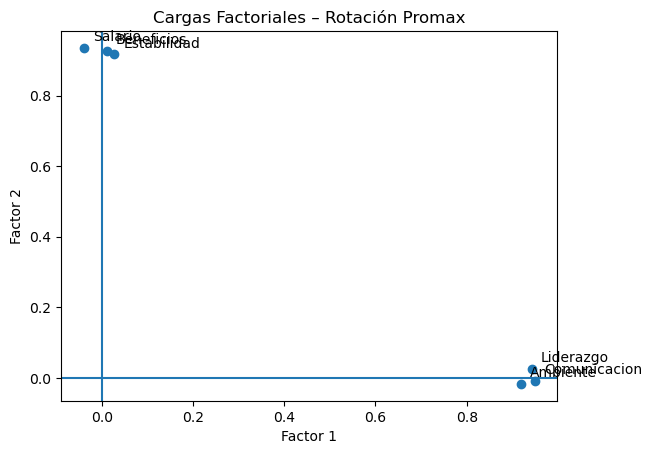

In [26]:
plt.figure()

plt.scatter(
    loadings_promax['Factor1'],
    loadings_promax['Factor2']
)

for i, var in enumerate(loadings_promax.index):
    plt.text(
        loadings_promax.iloc[i, 0] + 0.02,
        loadings_promax.iloc[i, 1] + 0.02,
        var
    )

plt.axhline(0)
plt.axvline(0)
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title('Cargas Factoriales – Rotación Promax')
plt.show()


* La estructura factorial es similar a Varimax

* Sin embargo, Promax no impone ortogonalidad

* Esto se confirma observando la matriz $phi$, que muestra correlación entre factores

## 9️ Comunalidades

Las comunalidades indican la proporción de varianza de cada variable explicada por los factores comunes. Valores superiores a 0.50 sugieren que las variables están bien representadas por el modelo factorial.

Variables con comunalidades bajas serían candidatas a eliminación o revisión.

In [27]:
pd.Series(
    fa_varimax.get_communalities(),
    index=X.columns
)

Ambiente        0.844476
Liderazgo       0.890271
Comunicacion    0.900969
Salario         0.874555
Estabilidad     0.841174
Beneficios      0.859469
dtype: float64

## 10 Alfa de Cronbach

El alfa de Cronbach evalúa la consistencia interna de los ítems asociados a cada factor. Valores superiores a 0.70 indican que los ítems miden coherentemente una misma dimensión latente, respaldando la validez interna de cada factor identificado.

In [16]:
def cronbach_alpha(df):
    k = df.shape[1]
    variances = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - variances.sum() / total_var)

alpha_f1 = cronbach_alpha(X[['Ambiente', 'Liderazgo', 'Comunicacion']])
alpha_f2 = cronbach_alpha(X[['Salario', 'Estabilidad', 'Beneficios']])

alpha_f1, alpha_f2

(0.9546660062773273, 0.9462409393963983)

## 1️1️ Conclusión

Los resultados confirman la existencia de una estructura factorial bidimensional, con buena adecuación muestral, correlaciones significativas, factores bien definidos y adecuada confiabilidad interna.

El análisis factorial confirma una estructura bidimensional clara, con buena adecuación muestral y consistencia interna.